# WZA block-Manhattan — CAP vs NO-CAP
**gen1 SNP × bio1 (Kendall-τ), hapFIRE BigLD blocks.**

Each point = one LD block at its genomic midpoint; y = −log10(WZA `Z_pVal`). We
contrast **no-cap** vs **SNP cap = 2000** (downsample big blocks, 100 resamples), for
both corrections: **deg-2** (canonical Booker) and **deg-7** (phase-1). CAM5 (block
`2_1265`, the phase-1 headline) is starred. Dashed line = BH q<0.05 threshold.

In [1]:
import sys
sys.path.insert(0, "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/wza_investigation")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import wza_core as wc

KEN = ("/global/scratch/users/tbellg/kmate/results/grenenet_gea/"
       "phase1_replication/kendall/kendall_snp_gen1_bio1.csv")
df = pd.read_csv(KEN); df = df[df.MAF >= 0.05].copy()

# block genomic position (chrom + median pos)
g = df.groupby("block")
pos = pd.DataFrame({"chrom": g.chrom.first(), "pos": g.pos.median()})

# raw weighted-Z per block, no-cap and cap2000
base  = wc.raw_wza(df, cap=None)
cap2k = wc.raw_wza(df, cap=2000)

def corrected(rw, deg, floor):
    w, _ = wc.apply_correction(rw, deg=deg, sd_floor=floor)
    return w.set_index("block").join(pos)

# deg-2 no-cap uses the SD safety-floor (canonical -> NaN; floor = the kMate hack);
# the floor crushes the giant blocks to p~1e-300, which we annotate as off-scale.
runs = {
    ("deg-2", "no cap"):  corrected(base,  2, True),
    ("deg-2", "cap2000"): corrected(cap2k, 2, False),
    ("deg-7", "no cap"):  corrected(base,  7, False),
    ("deg-7", "cap2000"): corrected(cap2k, 7, False),
}
print("blocks per panel:", {k: len(v) for k, v in runs.items()})

blocks per panel: {('deg-2', 'no cap'): 16179, ('deg-2', 'cap2000'): 16179, ('deg-7', 'no cap'): 16179, ('deg-7', 'cap2000'): 16179}


In [2]:
# cumulative x coordinates across Chr1..Chr5
CHROMS = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]
chrom_len = df.groupby("chrom")["pos"].max()
offset, off = {}, 0
for c in CHROMS:
    offset[c] = off; off += chrom_len[c] + 5e6          # 5 Mb gap between chroms
ticks = [offset[c] + chrom_len[c] / 2 for c in CHROMS]

def add_x(w):
    w = w.copy()
    w["x"] = w["pos"] + w["chrom"].map(offset)
    return w
runs = {k: add_x(v) for k, v in runs.items()}

def bh_thresh(p):
    v = p.dropna().sort_values(); n = len(v)
    q = v.to_numpy() * n / np.arange(1, n + 1)
    ok = q < 0.05
    return v.to_numpy()[ok].max() if ok.any() else np.nan   # largest BH-sig p
CAM5 = "2_1265"; YMAX = 14

## Manhattan grid — rows = correction degree, columns = cap setting
Points are clipped at −log10 p = 14 for readability; the number of off-scale blocks
(mostly the floored giant blocks under deg-2 no-cap) is annotated per panel.

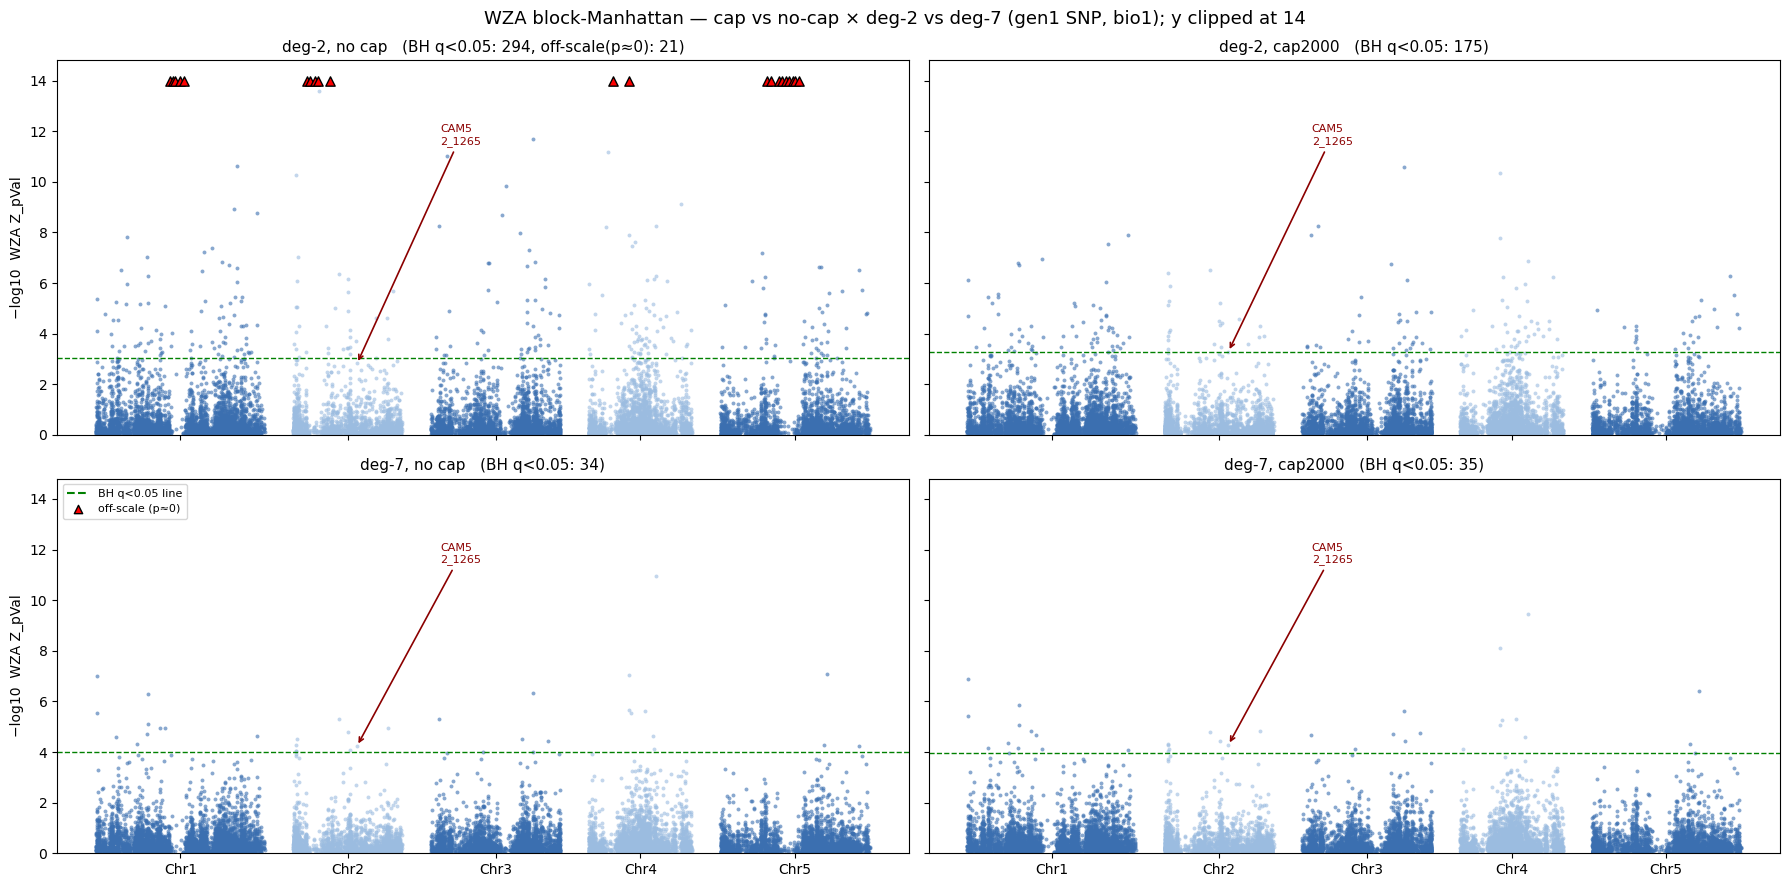

saved /global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/wza_investigation/results/fig9_manhattan_cap_vs_nocap.png


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True, sharey=True)
panels = [("deg-2", "no cap"), ("deg-2", "cap2000"),
          ("deg-7", "no cap"), ("deg-7", "cap2000")]
colors = {c: ("#3b6fb0" if i % 2 == 0 else "#9bbce0") for i, c in enumerate(CHROMS)}
for ax, key in zip(axes.flat, panels):
    w = runs[key]
    p = w["Z_pVal"]
    y = -np.log10(p.clip(lower=1e-300))
    off = y > YMAX           # off-scale (e.g. floored giant blocks at p=0)
    nan = p.isnull()
    yv = y.clip(upper=YMAX)
    for c in CHROMS:
        m = (w["chrom"] == c) & ~off & ~nan
        ax.scatter(w["x"][m], yv[m], s=8, c=colors[c], alpha=.6, linewidths=0)
    # off-scale blocks (spurious floored giants) as red triangles at the top
    if off.any():
        ax.scatter(w["x"][off], np.full(off.sum(), YMAX), marker="^", s=45,
                   color="red", edgecolor="k", zorder=6)
    bt = bh_thresh(p)
    nsig = int((p < bt).sum()) if np.isfinite(bt) else 0
    if np.isfinite(bt):
        ax.axhline(-np.log10(bt), color="green", ls="--", lw=1)
    # CAM5 annotated with an arrow (not a legend marker)
    if CAM5 in w.index:
        cy = min(-np.log10(max(w.loc[CAM5, "Z_pVal"], 1e-300)), YMAX)
        ax.annotate("CAM5\n2_1265", xy=(w.loc[CAM5, "x"], cy),
                    xytext=(w.loc[CAM5, "x"] + 1.5e7, YMAX - 2.5), fontsize=8, color="darkred",
                    arrowprops=dict(arrowstyle="->", color="darkred", lw=1.2))
    extra = f", off-scale(p≈0): {int(off.sum())}" if off.any() else ""
    extra += f", NaN: {int(nan.sum())}" if nan.any() else ""
    ax.set_title(f"{key[0]}, {key[1]}   (BH q<0.05: {nsig}{extra})", fontsize=11)
    ax.set_ylim(0, YMAX + 0.8)
axes[1, 0].plot([], [], color="green", ls="--", label="BH q<0.05 line")
axes[1, 0].scatter([], [], marker="^", color="red", edgecolor="k", label="off-scale (p≈0)")
axes[1, 0].legend(fontsize=8, loc="upper left")
for ax in axes[:, 0]:
    ax.set_ylabel("−log10  WZA Z_pVal")
for ax in axes[1, :]:
    ax.set_xticks(ticks); ax.set_xticklabels(CHROMS)
fig.suptitle("WZA block-Manhattan — cap vs no-cap × deg-2 vs deg-7 (gen1 SNP, bio1); y clipped at 14", fontsize=13)
fig.tight_layout()
OUT_PNG = "/global/scratch/users/tbellg/kmate/analysis/grenenet_gea/r2_gea_nonsnp/wza_investigation/results/fig9_manhattan_cap_vs_nocap.png"
fig.savefig(OUT_PNG, dpi=130); plt.show()
print("saved", OUT_PNG)

## Read-out
- **deg-7 (bottom row, the phase-1 method): the two Manhattans are nearly identical.**
  The cap does not change the peaks or CAM5 — results hold cap or no-cap.
- **deg-2 no-cap (top-left): a cluster of off-scale blocks** = the giant centromeric /
  large-LD blocks driven to p≈1e-300 by the SD safety-floor hack (spurious peaks).
  **deg-2 cap2000 (top-right)** removes them — the cap's real job is under deg-2.
- CAM5 (red star) is BH-significant in every panel; its height barely moves.
- The big visual difference is **between degrees** (deg-2 has many more peaks than
  deg-7), not between cap settings — consistent with the full comparison
  (`compare_cap_nocap.py`): degree is the lever, the cap is hygiene for deg-2.